# Step 2: Cross-Model Retina–DINOv2 Alignment Analysis

Compare representational similarity between primate retinal CNN layers (`conv0`, `conv1`, and readout **`linear`**) and DINOv2 ViT (ViT **`embeddings`** module, encoder layers 0–11, and block-0 sublayers) on the TVSD stimulus set.


## Metrics

- **RSA Spearman:** Spearman correlation of RDM upper triangles (geometric similarity of representational structure).

- **Linear CKA:** Centered Kernel Alignment with linear kernel (invariant to orthogonal transformations).

- **Ridge R² (A→B / B→A):** Cross-validated ridge regression R² predicting one representation from the other.

## Stimulus Set

All comparisons use **TVSDStimulusTrainSet** (grayscale ImageNet subset) with PCA reduction to 1000 components before RSA/CKA/ridge.

## Commands to generate results

From the project root (`bbscore_cs375_project_2026/`), run:

```bash
# conv0 vs all 12 DINOv2 encoders (RGB + grayscale)
for rb in 0 1 2 3 4 5 6 7 8 9 10 11; do
  python run_m2m.py --model-a retina_cnn --layer-a conv0 --model-b dinov2_base --layer-b _orig_mod.encoder.layer.$rb
  python run_m2m.py --model-a retina_cnn --layer-a conv0 --model-b dinov2_base_grayscale --layer-b _orig_mod.encoder.layer.$rb
done

# conv1 vs all 12 DINOv2 encoders (RGB + grayscale)
for rb in 0 1 2 3 4 5 6 7 8 9 10 11; do
  python run_m2m.py --model-a retina_cnn --layer-a conv1 --model-b dinov2_base --layer-b _orig_mod.encoder.layer.$rb
  python run_m2m.py --model-a retina_cnn --layer-a conv1 --model-b dinov2_base_grayscale --layer-b _orig_mod.encoder.layer.$rb
done
```

```bash
# conv1 and conv2 vs all DINOv2 embeddings (RGB + grayscale)
for ra in conv0 conv1; do
  for lb in _orig_mod.embeddings; do
    python run_m2m.py --model-a retina_cnn --layer-a $ra --model-b dinov2_base --layer-b $lb
    python run_m2m.py --model-a retina_cnn --layer-a $ra --model-b dinov2_base_grayscale --layer-b $lb
  done
done
```

Results are saved to `bbscore_data/results/CrossModel_*.pkl`.

In [13]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths (match step1_v1_match_analysis)
RESULTS_DIR = "/Volumes/Lab/Users/xzhou25/bbscore_cs375_project_2026/bbscore_data/results"

# Block-level plots: ViT embeddings module (index -1) + encoder layers 0..11; patch_embeddings excluded
DINOV2_BLOCK_LAYER_TICKS = list(range(-1, 12))
DINOV2_BLOCK_LAYER_LABELS = ["embeddings"] + [f"encoder {i}" for i in range(12)]

def _extract_cross_model_scores(metrics):
    """Extract cross_model scores from metrics (dict or list of dicts)."""
    entries = [metrics] if isinstance(metrics, dict) else metrics
    if not entries:
        return None
    for m in reversed(entries):
        if not isinstance(m, dict):
            continue
        cm = m.get("cross_model", m)
        scores = cm.get("cross_model", cm) if isinstance(cm, dict) else cm
        if isinstance(scores, dict) and "error" not in scores:
            return scores
    return None

def load_cross_model_results():
    """Load all CrossModel_retina_cnn_*_vs_dinov2_*.pkl files (block-level, sublayers, embeddings)."""
    # Encoder layers: layer_0, layer_1, ... and layer_0_norm1, layer_0_attention, etc.
    pattern_encoder = re.compile(
        r"CrossModel_retina_cnn_(conv[01])_vs_(dinov2_base(?:_grayscale)?)__orig_mod_encoder_layer_(\d+)(?:_([a-z0-9]+))?\.pkl"
    )
    # Pre-transformer embeddings: _orig_mod_embeddings only (patch_embeddings files skipped)
    pattern_embeddings = re.compile(
        r"CrossModel_retina_cnn_(conv[01])_vs_(dinov2_base(?:_grayscale)?)__orig_mod_embeddings(_patch_embeddings)?\.pkl"
    )
    data = []
    for fname in os.listdir(RESULTS_DIR):
        path = os.path.join(RESULTS_DIR, fname)
        m = pattern_encoder.match(fname)
        if m:
            retina_layer, dinov2_variant, layer_idx, sublayer = m.groups()
            layer_int = int(layer_idx)
        else:
            m = pattern_embeddings.match(fname)
            if not m:
                continue
            retina_layer, dinov2_variant, patch_suffix = m.groups()
            if patch_suffix:
                continue  # omit patch_embeddings; analysis uses embeddings module only
            sublayer = None
            layer_int = -1
        with open(path, "rb") as f:
            d = pickle.load(f)
        scores = _extract_cross_model_scores(d.get("metrics"))
        if scores is None:
            print(f"Skipping (no valid scores): {fname}")
            continue
        data.append({
            "retina_layer": retina_layer,
            "dinov2_variant": dinov2_variant,
            "dinov2_layer": layer_int,
            "dinov2_sublayer": sublayer,
            **scores,
        })
    return pd.DataFrame(data)

df = load_cross_model_results()
df_block = df[df["dinov2_sublayer"].isna()].copy()
df_sublayer = df[df["dinov2_sublayer"].notna()].copy()
print(f"Loaded {len(df)} cross-model results ({len(df_block)} block-level, {len(df_sublayer)} sublayer)")
print("Block-level (embeddings=-1, encoder 0-11; patch_embedding files skipped):")
print(df_block[["retina_layer", "dinov2_variant", "dinov2_layer"]].drop_duplicates().sort_values(["retina_layer", "dinov2_variant", "dinov2_layer"]).to_string(index=False))
if len(df_sublayer) > 0:
    print("\nSublayer (block 0):")
    print(df_sublayer[["retina_layer", "dinov2_variant", "dinov2_sublayer"]].drop_duplicates().sort_values(["retina_layer", "dinov2_variant", "dinov2_sublayer"]).to_string(index=False))

Loaded 68 cross-model results (52 block-level, 16 sublayer)
Block-level (embeddings=-1, encoder 0-11; patch_embedding files skipped):
retina_layer        dinov2_variant  dinov2_layer
       conv0           dinov2_base            -1
       conv0           dinov2_base             0
       conv0           dinov2_base             1
       conv0           dinov2_base             2
       conv0           dinov2_base             3
       conv0           dinov2_base             4
       conv0           dinov2_base             5
       conv0           dinov2_base             6
       conv0           dinov2_base             7
       conv0           dinov2_base             8
       conv0           dinov2_base             9
       conv0           dinov2_base            10
       conv0           dinov2_base            11
       conv0 dinov2_base_grayscale            -1
       conv0 dinov2_base_grayscale             0
       conv0 dinov2_base_grayscale             1
       conv0 dinov2_base_grayscal

In [14]:
# Pivot to wide format: (retina_layer, dinov2_variant) -> DataFrame indexed by dinov2_layer
METRIC_KEYS = ["rsa_spearman", "rsa_corr", "linear_cka", "rbf_cka", "ridge_r2_A_to_B", "ridge_r2_B_to_A"]

def build_pivot(data, metric):
    """Build pivot table: rows=dinov2_layer (-1 embeddings, 0-11 encoder), columns=(retina_layer, dinov2_variant)."""
    if metric not in data.columns:
        return None
    piv = data.pivot_table(
        index="dinov2_layer",
        columns=["retina_layer", "dinov2_variant"],
        values=metric,
        aggfunc="first",
    )
    return piv

# Summary: best DINOv2 layer per (retina_layer, dinov2_variant) for RSA Spearman (commented out for later)
piv_rsa = build_pivot(df_block, "rsa_spearman")
if piv_rsa is not None:
    print("RSA Spearman — best DINOv2 layer per condition:")
    for col in piv_rsa.columns:
        best_idx = piv_rsa[col].idxmax()
        print(f"  {col}: layer {best_idx} (r={piv_rsa.loc[best_idx, col]:.4f})")
    print()
    display(piv_rsa.round(4))

RSA Spearman — best DINOv2 layer per condition:
  ('conv0', 'dinov2_base'): layer 0 (r=0.3201)
  ('conv0', 'dinov2_base_grayscale'): layer -1 (r=0.4374)
  ('conv1', 'dinov2_base'): layer 0 (r=0.2445)
  ('conv1', 'dinov2_base_grayscale'): layer 0 (r=0.3229)



retina_layer         conv0                             conv1  \
dinov2_variant dinov2_base dinov2_base_grayscale dinov2_base   
dinov2_layer                                                   
-1                  0.2820                0.4374      0.1989   
 0                  0.3201                0.4219      0.2445   
 1                  0.2851                0.3337      0.2269   
 2                  0.2064                0.2324      0.1724   
 3                  0.1908                0.2197      0.1636   
 4                  0.1548                0.1780      0.1404   
 5                  0.1412                0.1640      0.1340   
 6                  0.1120                0.1239      0.1103   
 7                  0.0882                0.0982      0.0934   
 8                  0.0125                0.0137      0.0158   
 9                  0.0134                0.0146      0.0170   
 10                 0.0155                0.0166      0.0201   
 11                 0.0303                0.0321      0.0409   

retina_layer                          
dinov2_variant dinov2_base_grayscale  
dinov2_layer                          
-1                            0.3044  
 0                            0.3229  
 1                            0.2629  
 2                            0.1914  
 3                            0.1841  
 4                            0.1567  
 5                            0.1506  
 6                            0.1177  
 7                            0.1004  
 8                            0.0174  
 9                            0.0185  
 10                           0.0214  
 11                           0.0423

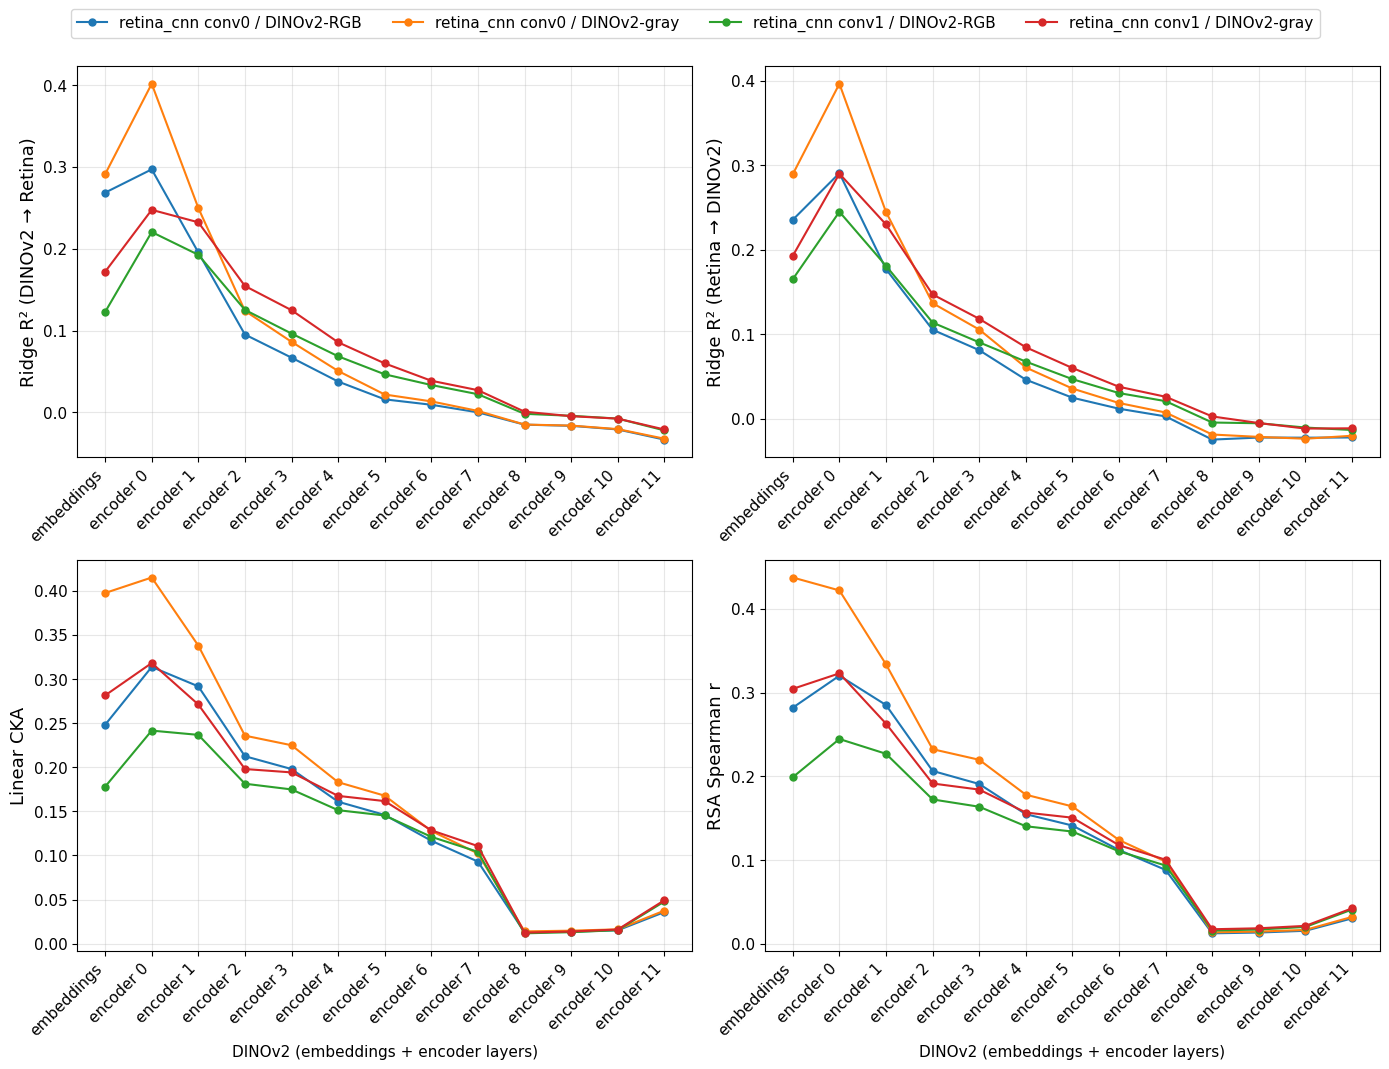

In [15]:
# Master plot: four metrics on the same 4-line layout (conv0/conv1 × RGB/grayscale)
LABEL_MAP = [
    ("conv0", "dinov2_base", "retina_cnn conv0 / DINOv2-RGB", "C0", "-o"),
    ("conv0", "dinov2_base_grayscale", "retina_cnn conv0 / DINOv2-gray", "C1", "-o"),
    ("conv1", "dinov2_base", "retina_cnn conv1 / DINOv2-RGB", "C2", "-o"),
    ("conv1", "dinov2_base_grayscale", "retina_cnn conv1 / DINOv2-gray", "C3", "-o"),
]

# Match step1_v1_match_analysis per-voxel block (figure row size + fonts)
_fig_w, _fig_h = 14, 5.5
_fs_xtick, _fs_ytick = 11, 11
_fs_panel = 13


def _plot_block_metric(ax, colname, ylabel, show_x_ticks=True, show_xlabel=True):
    for retina_layer, variant, label, color, style in LABEL_MAP:
        sub = df_block[(df_block["retina_layer"] == retina_layer) & (df_block["dinov2_variant"] == variant)]
        v = sub.sort_values("dinov2_layer")
        vals = v[colname].replace([np.nan, np.inf, -np.inf], np.nan)
        ax.plot(v["dinov2_layer"], vals, style, label=label, color=color, markersize=5)
    ax.set_xticks(DINOV2_BLOCK_LAYER_TICKS)
    ax.set_xticklabels(
        DINOV2_BLOCK_LAYER_LABELS, rotation=45, ha="right", fontsize=_fs_xtick,
    )
    ax.tick_params(axis="y", labelsize=_fs_ytick)
    if not show_x_ticks:
        ax.tick_params(axis="x", labelbottom=False)
    if show_xlabel:
        ax.set_xlabel("DINOv2 (embeddings + encoder layers)", fontsize=_fs_xtick)
    else:
        ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=_fs_panel)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(_fig_w, _fig_h * 2), sharex=True)
# Top left: DINOv2 → Retina; top right: Retina → DINOv2 (model A = retina, B = DINOv2)
_plot_block_metric(axes[0, 0], "ridge_r2_B_to_A", "Ridge R² (DINOv2 → Retina)", show_xlabel=False)
_plot_block_metric(axes[0, 1], "ridge_r2_A_to_B", "Ridge R² (Retina → DINOv2)", show_xlabel=False)
_plot_block_metric(axes[1, 0], "linear_cka", "Linear CKA")
_plot_block_metric(axes[1, 1], "rsa_spearman", "RSA Spearman r")
# sharex hides x tick labels on non-outer axes; restore layer names on the top row
for ax in axes[0, :]:
    ax.tick_params(axis="x", labelbottom=True)
plt.tight_layout(rect=[0, 0, 1, 0.93])
_handles, _labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    _handles,
    _labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=4,
    fontsize=_fs_xtick,
)
_match_path = os.path.join(os.path.dirname(os.path.dirname(RESULTS_DIR)), "project", "report", "figures", "match_across_layers.png")
os.makedirs(os.path.dirname(_match_path), exist_ok=True)
fig.savefig(_match_path, dpi=300, bbox_inches="tight")
plt.show()

## Block 0 Sublayer Analysis

Within DINOv2 transformer block 0, we compare retina layers to each sublayer:

- **norm1:** Normalized patch embedding (pre-attention, most local)
- **attention:** Multi-head self-attention output (relational)
- **mlp:** Feed-forward network output (local refinement)
- **norm2:** Normalized attention output (pre-MLP)

This reveals whether retinal alignment is driven by local (norm1, mlp) or relational (attention) processing.

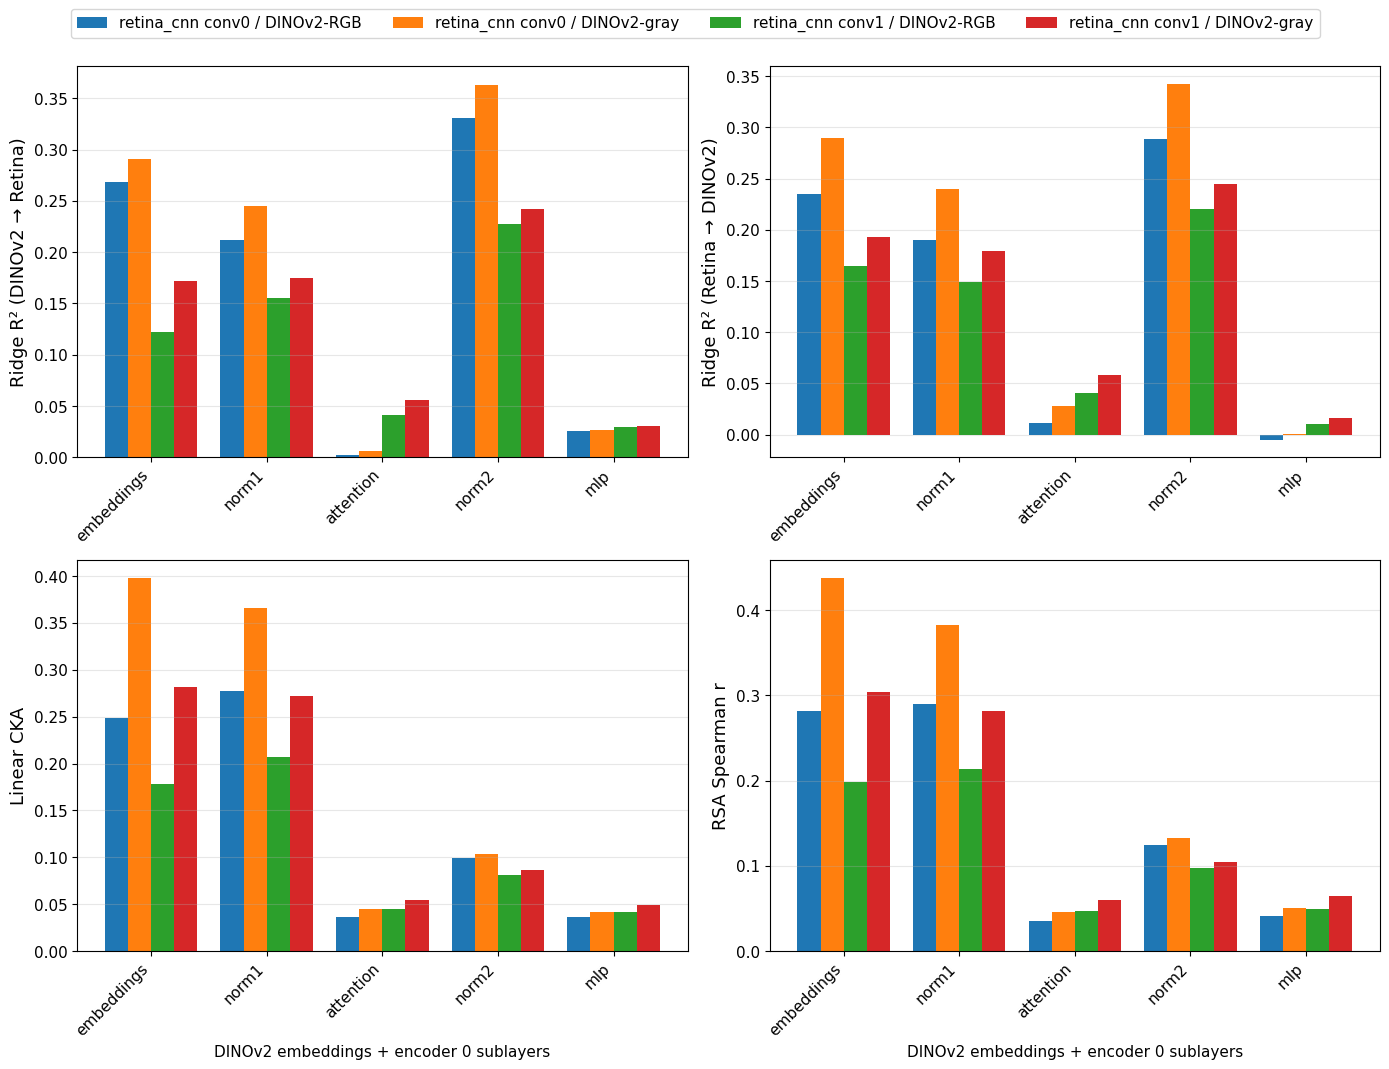

In [16]:
# Master sublayer plot: four metrics, grouped bars (ViT embeddings + DINOv2 encoder 0 sublayers)
# Embeddings use the same block-level rows as match_across_layers (dinov2_layer == -1).
if len(df_sublayer) == 0:
    print("No sublayer results found. Run the sublayer cross-model comparisons first.")
else:
    LABEL_MAP = [
        ("conv0", "dinov2_base", "retina_cnn conv0 / DINOv2-RGB", "C0"),
        ("conv0", "dinov2_base_grayscale", "retina_cnn conv0 / DINOv2-gray", "C1"),
        ("conv1", "dinov2_base", "retina_cnn conv1 / DINOv2-RGB", "C2"),
        ("conv1", "dinov2_base_grayscale", "retina_cnn conv1 / DINOv2-gray", "C3"),
    ]
    SUBLAYER_ORDER = ["norm1", "attention", "norm2", "mlp"]
    # First bar: pre-transformer embeddings (same label as DINOV2_BLOCK_LAYER_LABELS[0])
    BAR_X_LABELS = [DINOV2_BLOCK_LAYER_LABELS[0]] + SUBLAYER_ORDER
    df_sub = df_sublayer[df_sublayer["dinov2_sublayer"].isin(SUBLAYER_ORDER)].copy()
    df_sub["dinov2_sublayer"] = pd.Categorical(
        df_sub["dinov2_sublayer"], categories=SUBLAYER_ORDER, ordered=True
    )

    _fig_w, _fig_h = 14, 5.5
    _fs_xtick, _fs_ytick = 11, 11
    _fs_panel = 13
    _xs = np.arange(len(BAR_X_LABELS))
    _n_series = len(LABEL_MAP)
    _bar_w = 0.8 / _n_series
    _offsets = (np.arange(_n_series) - (_n_series - 1) / 2) * _bar_w

    def _plot_sublayer_metric(
        ax,
        colname,
        ylabel,
        show_x_ticks=True,
        show_xlabel=True,
    ):
        for k, (retina_layer, variant, label, color) in enumerate(LABEL_MAP):
            emb = df_block[
                (df_block["retina_layer"] == retina_layer)
                & (df_block["dinov2_variant"] == variant)
                & (df_block["dinov2_layer"] == -1)
            ]
            emb_val = np.nan
            if len(emb) > 0:
                emb_val = emb[colname].iloc[0]
            sub = df_sub[
                (df_sub["retina_layer"] == retina_layer)
                & (df_sub["dinov2_variant"] == variant)
            ]
            v = sub.set_index("dinov2_sublayer").reindex(SUBLAYER_ORDER)
            sub_vals = v[colname].replace([np.nan, np.inf, -np.inf], np.nan)
            vals = pd.Series([emb_val] + sub_vals.tolist()).replace(
                [np.nan, np.inf, -np.inf], np.nan
            )
            ax.bar(
                _xs + _offsets[k],
                vals,
                width=_bar_w,
                label=label,
                color=color,
            )
        ax.set_xticks(_xs)
        ax.set_xticklabels(
            BAR_X_LABELS, rotation=45, ha="right", fontsize=_fs_xtick,
        )
        ax.tick_params(axis="y", labelsize=_fs_ytick)
        if not show_x_ticks:
            ax.tick_params(axis="x", labelbottom=False)
        if show_xlabel:
            ax.set_xlabel(
                "DINOv2 embeddings + encoder 0 sublayers", fontsize=_fs_xtick
            )
        else:
            ax.set_xlabel("")
        ax.set_ylabel(ylabel, fontsize=_fs_panel)
        ax.grid(True, alpha=0.3, axis="y")

    fig, axes = plt.subplots(2, 2, figsize=(_fig_w, _fig_h * 2), sharex=True)
    _plot_sublayer_metric(
        axes[0, 0], "ridge_r2_B_to_A", "Ridge R² (DINOv2 → Retina)", show_xlabel=False
    )
    _plot_sublayer_metric(
        axes[0, 1], "ridge_r2_A_to_B", "Ridge R² (Retina → DINOv2)", show_xlabel=False
    )
    _plot_sublayer_metric(axes[1, 0], "linear_cka", "Linear CKA")
    _plot_sublayer_metric(axes[1, 1], "rsa_spearman", "RSA Spearman r")
    # sharex hides x tick labels on non-outer axes; restore layer names on the top row
    for ax in axes[0, :]:
        ax.tick_params(axis="x", labelbottom=True)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    _handles, _labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        _handles,
        _labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.935),
        ncol=4,
        fontsize=_fs_xtick,
    )
    _sublayer_path = os.path.join(os.path.dirname(os.path.dirname(RESULTS_DIR)),"project","report","figures","match_encoder0_sublayer.png")
    os.makedirs(os.path.dirname(_sublayer_path), exist_ok=True)
    fig.savefig(_sublayer_path, dpi=300, bbox_inches="tight")
    plt.show()


In [17]:
# Sublayer summary table (block 0) — Linear CKA only
if len(df_sublayer) > 0:
    SUBLAYER_ORDER = ["norm1", "attention", "mlp", "norm2"]
    df_sub = df_sublayer[df_sublayer["dinov2_sublayer"].isin(SUBLAYER_ORDER)].copy()
    sub_piv = df_sub.pivot_table(
        index=["retina_layer", "dinov2_variant"],
        columns="dinov2_sublayer",
        values="linear_cka",
        aggfunc="first",
        observed=False,
    )
    sub_piv.index = [f"retina_cnn {r} / {'DINOv2-RGB' if v == 'dinov2_base' else 'DINOv2-gray'}" for (r, v) in sub_piv.index]
    display(sub_piv.round(4))

dinov2_sublayer,attention,mlp,norm1,norm2
retina_cnn conv0 / DINOv2-RGB,0.0364,0.0365,0.2772,0.0990
retina_cnn conv0 / DINOv2-gray,0.0452,0.0416,0.3658,0.1037
retina_cnn conv1 / DINOv2-RGB,0.0450,0.0421,0.2064,0.0814
retina_cnn conv1 / DINOv2-gray,0.0542,0.0494,0.2718,0.0863


In [18]:
# Full metrics table (sample: conv0 vs dinov2_base)
sample = df_block[(df_block["retina_layer"] == "conv0") & (df_block["dinov2_variant"] == "dinov2_base")].sort_values("dinov2_layer")
display_cols = ["dinov2_layer"] + [c for c in METRIC_KEYS if c in sample.columns]
display(sample[display_cols].set_index("dinov2_layer").round(4))

,rsa_spearman,rsa_corr,linear_cka,rbf_cka,ridge_r2_A_to_B,ridge_r2_B_to_A
dinov2_layer,,,,,,
-1,0.2820,0.2511,0.2481,NaN,0.2355,0.2685
0,0.3201,0.3274,0.3137,0.1974,0.2906,0.2970
1,0.2851,0.2938,0.2916,0.2451,0.1771,0.1954
2,0.2064,0.2119,0.2125,0.2002,0.1053,0.0951
3,0.1908,0.1977,0.1979,0.1954,0.0812,0.0668
4,0.1548,0.1615,0.1609,NaN,0.0463,0.0376
5,0.1412,0.1473,0.1459,NaN,0.0249,0.0159
6,0.1120,0.1169,0.1166,NaN,0.0119,0.0092
7,0.0882,0.0926,0.0930,NaN,0.0028,-0.0000
